In [ ]:
# Install the required dependencies for preprocessing, modeling, and evaluation.
%pip install -q tiktoken
%pip install -Uq sentencepiece protobuf
%pip install -Uq transformers tokenizers
%pip install -q emoji ekphrasis
%pip install -q beautifulsoup4 scikit-learn

In [ ]:
# Import all libraries used for text preprocessing, training, and evaluation.
from ekphrasis.classes.preprocessor import TextPreProcessor
from sklearn.utils.class_weight import compute_class_weight
from ekphrasis.classes.tokenizer import SocialTokenizer
from torch.utils.data import Dataset, DataLoader


from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score
from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, logging, BertTokenizer, BertModel
from bs4 import BeautifulSoup, MarkupResemblesLocatorWarning
from dataclasses import dataclass
from typing import Any
from tqdm import tqdm

import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd
import numpy as np

import warnings
import emoji
import torch
import json
import os
import re

logging.set_verbosity_error()
logging.disable_progress_bar()
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

In [ ]:
# Set global hyperparameters, random seeds, output paths, and the execution device.
SEED = 42
MAX_LENGTH = 128
BATCH_SIZE = 16
LR = 2e-5
EPOCHS = 20

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BasePath = "/content/drive/MyDrive/Toxic Speech Identification/toxic_classifier_de"
    BasePath_dataset = "/content/drive/MyDrive/Toxic Speech Identification/toxic_classifier_de"
    OUTPUT_DIR = os.path.join(BasePath, 'emobot_de')
except ModuleNotFoundError:
    print("Not running in Colab, skipping Drive mount.")
    BasePath = os.getcwd()
    BasePath_dataset = BasePath
    OUTPUT_DIR = os.path.join(BasePath, 'emobot_de')

os.makedirs(OUTPUT_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# List the candidate Hugging Face models to test. Uncomment the ones you want to run.
models = (
    #"microsoft/mdeberta-v3-base",
    #"autopilot-ai/EthicalEye",
    #"deepset/gelectra-large",
    #"deepset/gbert-large",                 # not working
    #"deepset/gelectra-base",
    #"deepset/gbert-base",
    #"studio-ousia/mluke-base",
    #"dbmdz/bert-base-german-cased",
    #"bert-base-multilingual-cased",
    #"bert-base-multilingual-uncased",
   #"FacebookAI/xlm-roberta-base",
    #"FacebookAI/xlm-roberta-large",
    #"answerdotai/ModernBERT-base",
    "LSX-UniWue/ModernGBERT_1B",               # CUDA out of memory
    #"GottBERT/GottBERT_base_last",
    #"GeistBERT/GeistBERT_base",
    #"deepset/bert-base-german-cased-hatespeech-GermEval18Coarse",
)

In [ ]:
# Define label vocabularies and helper functions for label normalization/canonicalization.
toxicity_labels = ["Explicit", "Implicit", "Neutral"]
toxicity2id = {l: i for i, l in enumerate(toxicity_labels)}
id2toxicity = {i: l for l, i in toxicity2id.items()}
NUM_TOX = len(toxicity_labels)
print(toxicity_labels)

# Bias Type (SINGLE-CHOICE incl. None)
bias_labels = [
    "Political / Ideological Bias",
    "Migration / Ethnic Bias",
    "Religious Bias",
    "Institutional / Media Bias",
    "Socioeconomic / Educational Bias",
    "Cognitive / Intelligence bias",
    "Gender / Identity bias",
    "Appearance / Physical Bias",
    "None",
]
bias2id = {l: i for i, l in enumerate(bias_labels)}
id2bias = {i: l for l, i in bias2id.items()}
NUM_BIAS = len(bias_labels)

# Target Type (4-class incl. None)
target_labels = ["Individual", "Group", "Other", "None"]
target2id = {l: i for i, l in enumerate(target_labels)}
id2target = {i: l for l, i in target2id.items()}
NUM_TARGET = len(target_labels)

# ----------------- Canonicalization helpers -----------------


def _norm_label(s: Any) -> str:
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip()
    s = " ".join(s.split())
    s = s.replace("/", " / ")
    s = " ".join(s.split())
    return s


_BIAS_ALIASES = {
    "Political/Ideological Bias": "Political / Ideological Bias",
    "Political / Ideological Bias": "Political / Ideological Bias",
    "Migration/Ethnic Bias": "Migration / Ethnic Bias",
    "Migration / Ethnic Bias": "Migration / Ethnic Bias",
    "Institutional/Media Bias": "Institutional / Media Bias",
    "Institutional / Media Bias": "Institutional / Media Bias",
    "Socioeconomic/Educational Bias": "Socioeconomic / Educational Bias",
    "Socioeconomic / Educational Bias": "Socioeconomic / Educational Bias",
    "Cognitive / Intelligence Bias": "Cognitive / Intelligence bias",
    "Cognitive / Intelligence bias": "Cognitive / Intelligence bias",
    "Gender / Identity Bias": "Gender / Identity bias",
    "Gender / Identity bias": "Gender / Identity bias",
    "Appearance / Physical Bias": "Appearance / Physical Bias",
    "Religious Bias": "Religious Bias",
    "None": "None",
}


def canon_toxicity(x: Any) -> str:
    s = _norm_label(x).lower()
    # English canonical
    if s.lower() == "explicit":
        return "Explicit"
    if s.lower() == "implicit":
        return "Implicit"
    if s.lower() == "neutral":
        return "Neutral"
    # If Greek labels exist, we will extend this mapping in next cell.
    raise ValueError(f"Unknown toxicity label: {x}")


def canon_bias(x: Any) -> str:
    s = _norm_label(x)
    if s == "":
        return "None"
    if s in _BIAS_ALIASES:
        return _BIAS_ALIASES[s]
    for k, v in _BIAS_ALIASES.items():
        if s.lower() == k.lower():
            return v
    return "None"


def canon_target(x: Any) -> str:
    s = _norm_label(x)
    if s == "":
        return "None"
    s_low = s.lower()
    if s_low == "individual":
        return "Individual"
    if s_low == "group":
        return "Group"
    if s_low == "other":
        return "Other"
    if s_low == "none":
        return "None"
    # If Greek labels exist, we will extend this mapping in next cell.
    raise ValueError(f"Unknown target label: {x}")

['Explicit', 'Implicit', 'Neutral']


In [ ]:
# Load the German dataset, validate the expected schema, clean missing values, and save a normalized copy.
# 1) Path to the German file (replace it with your own file if needed)
# <-- update this path to point to your own dataset
DATA_PATH = os.path.join(BasePath_dataset, "german_tox_emobot_dataset1.xlsx")
SHEET = 0

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET)

print("Columns:", df_raw.columns.tolist())
print("Rows:", len(df_raw))

# 2) Check that the expected columns exist
expected_cols = ["text_id", "text", "toxicity", "bias_type", "target_type"]
missing = [c for c in expected_cols if c not in df_raw.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}. Found: {df_raw.columns.tolist()}")

# 3) Fix NaN values: in this schema, NaN means "None"
print("NaN bias_type before:", df_raw["bias_type"].isna().sum())
print("NaN target_type before:", df_raw["target_type"].isna().sum())

df_raw["bias_type"] = df_raw["bias_type"].fillna("None")
df_raw["target_type"] = df_raw["target_type"].fillna("None")

print("NaN bias_type after:", df_raw["bias_type"].isna().sum())
print("NaN target_type after:", df_raw["target_type"].isna().sum())

# 4) Basic cleaning (keep the original language characters intact)
df_raw["text"] = df_raw["text"].astype(str)
df_raw["toxicity"] = df_raw["toxicity"].astype(str).str.strip()
df_raw["bias_type"] = df_raw["bias_type"].astype(str).str.strip()
df_raw["target_type"] = df_raw["target_type"].astype(str).str.strip()

# 5) (Optional but recommended) Save a cleaned copy to Drive/output folder
# CLEAN_PATH = os.path.join(BasePath, "emobot_de", "clean_de_annotations.xlsx")
# df_raw.to_excel(CLEAN_PATH, index=False)
# print("Saved cleaned file to:", CLEAN_PATH)

# df_raw.head(3)

Columns: ['text_id', 'text', 'toxicity', 'bias_type', 'target_type']
Rows: 8054
NaN bias_type before: 3184
NaN target_type before: 2388
NaN bias_type after: 0
NaN target_type after: 0


In [ ]:
# Text preprocessing utilities: emoji normalization and lightweight cleaning for German social media text.
def emojis_into_text(sentence: str) -> str:
    """
    Take a string that contains emojis and replace them with textual labels.
    Example: 😀 -> grinning face
    """
    demojized_sent = emoji.demojize(sentence)  # 😀 → :grinning_face:
    emoji_txt = re.sub(
        r':[\S]+:',
        lambda x: x.group().replace('_', ' ')
                           .replace('-', ' ')
                           .replace(':', ''),
        demojized_sent,
    )
    return emoji_txt


# Ekphrasis preprocessor (OK for EL social text)
text_processor = TextPreProcessor(
    annotate={'hashtag'},
    segmenter='twitter',
    corrector='twitter',
    fix_html=True,
    fix_text=True,
    unpack_hashtags=True,
    unpack_contractions=True,
    spell_correct_deong=True,
    tokenizer=SocialTokenizer(lowercase=True).tokenize,
)


def preprocessing(text) -> str:
    """
    Lightweight preprocessing for German tweets/comments.
    Do not remove language-specific characters or diacritics.
    """
    # If the input arrives as bytes, remove the BOM first
    try:
        text = text.decode("utf-8-sig").replace("\ufffd", "?")
    except Exception:
        pass

    # Convert HTML content to clean text
    soup = BeautifulSoup(str(text), "lxml")
    text = soup.get_text()

    # RT patterns
    text = re.sub(r"^RT\s+@\w+:\s*", "", text)   # RT @user:
    text = re.sub(r"^RT:\s*", "", text)          # RT:

    # Mentions (unicode-safe)
    text = re.sub(r"@\w+", "", text)

    # URLs
    text = re.sub(r"http(s?)://\S+", "", text)
    text = re.sub(r"www\.\S+", "", text)

    # Remove leftover tokens such as url/html/http
    for u in ["url", "URL", "html", "HTML", "http", "HTTP"]:
        text = re.sub(rf"\b{re.escape(u)}\b", "", text)

    # Emojis -> text
    text = emojis_into_text(text)

    # Normalize ampersands to the German word "und"
    text = re.sub(r"&amp;", " und ", text)
    text = re.sub(r"&", " und ", text)

    # Normalize apostrophe variants
    text = re.sub(r"’", "'", text)

    # Collapse repeated spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Ekphrasis normalization/tokenization
    text = " ".join(text_processor.pre_process_doc(text))

    return text


temp_df = df_raw.copy()
temp_df["text"] = temp_df["text"].apply(preprocessing)
temp_df.to_excel(os.path.join(
    OUTPUT_DIR, "preproc_dataset_de.xlsx"), index=False)
del temp_df

Word statistics files not found!
Downloading... 

/usr/local/lib/python3.12/dist-packages/ekphrasis/classes/tokenizer.py:225: FutureWarning: Possible nested set at position 2190
  self.tok = re.compile(r"({})".format("|".join(pipeline)))


done!
Unpacking... done!
Reading twitter - 1grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_1grams.txt
Reading twitter - 2grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_2grams.txt


/usr/local/lib/python3.12/dist-packages/ekphrasis/classes/exmanager.py:14: FutureWarning: Possible nested set at position 42
  regexes = {k.lower(): re.compile(self.expressions[k]) for k, v in


Reading twitter - 1grams ...


In [ ]:
# Dataset class that applies preprocessing and tokenization before feeding batches to the model.
class EmobotDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128, apply_preproc=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.apply_preproc = apply_preproc

        # Sanity checks so failures happen early if something is missing
        needed = ["text", "tox_id", "bias_id", "tgt_id"]
        missing = [c for c in needed if c not in self.df.columns]
        if missing:
            raise ValueError(
                f"Missing columns in df: {missing}. Found: {self.df.columns.tolist()}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        raw_text = "" if pd.isna(row["text"]) else str(row["text"])

        # IMPORTANT: apply the same preprocessing during training and inference
        text = preprocessing(raw_text) if self.apply_preproc else raw_text

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels_tox": torch.tensor(int(row["tox_id"]), dtype=torch.long),
            "labels_bias": torch.tensor(int(row["bias_id"]), dtype=torch.long),
            "labels_tgt": torch.tensor(int(row["tgt_id"]), dtype=torch.long),
            "text": raw_text
        }
        return item


def collate_fn(batch):
    out = {}

    for k in batch[0].keys():
        if k == "text":
            out[k] = [b[k] for b in batch]  # list of strings
        else:
            out[k] = torch.stack([b[k] for b in batch], dim=0)

    return out

In [ ]:
# Convert textual labels to IDs and enforce the rule that neutral samples map to bias=None and target=None.
# =========================
# CELL: Mapping / Processing
# creates: df with tox_id, bias_id, tgt_id
# schema: bias single-choice + None, target 4-class + None
# masking rule: if toxicity == Neutral -> bias=None, target=None
# =========================

# 0) Start from raw
df = df_raw.copy()

# 1) Ensure text exists
df["text"] = df["text"].astype(str)

# 2) Canonicalize labels (uses canon_* functions from your settings cell)
#    NOTE: if your Greek Excel uses Greek strings, we will extend canon_* later.
df["toxicity"] = df["toxicity"].apply(canon_toxicity)
df["bias_type"] = df["bias_type"].apply(canon_bias)
df["target_type"] = df["target_type"].apply(canon_target)

# 3) Apply masking rule (schema logic)
neutral_mask = df["toxicity"].eq("Neutral")
df.loc[neutral_mask, "bias_type"] = "None"
df.loc[neutral_mask, "target_type"] = "None"

# 4) Map to ids (single-choice)
df["tox_id"] = df["toxicity"].map(toxicity2id)
df["bias_id"] = df["bias_type"].map(bias2id)
df["tgt_id"] = df["target_type"].map(target2id)

# 5) Sanity checks: no unmapped
print("Unmapped tox_id:", df["tox_id"].isna().sum())
print("Unmapped bias_id:", df["bias_id"].isna().sum())
print("Unmapped tgt_id:", df["tgt_id"].isna().sum())

# If any unmapped exists, print examples
if df["tox_id"].isna().any():
    print("\nExamples of unmapped toxicity:")
    print(df.loc[df["tox_id"].isna(), ["toxicity"]].head(10))

if df["bias_id"].isna().any():
    print("\nExamples of unmapped bias_type:")
    print(df.loc[df["bias_id"].isna(), ["bias_type"]].head(10))

if df["tgt_id"].isna().any():
    print("\nExamples of unmapped target_type:")
    print(df.loc[df["tgt_id"].isna(), ["target_type"]].head(10))

# Hard fail if unmapped labels exist
if df[["tox_id", "bias_id", "tgt_id"]].isna().any().any():
    raise ValueError(
        "Found unmapped labels. Fix canon_* mappings or Excel label strings.")

# 6) Convert ids to int
df["tox_id"] = df["tox_id"].astype(int)
df["bias_id"] = df["bias_id"].astype(int)
df["tgt_id"] = df["tgt_id"].astype(int)

# 7) Quick view
print("\n✅ Mapping done. Quick check:")
print(df[["text_id", "toxicity", "bias_type", "target_type",
      "tox_id", "bias_id", "tgt_id"]].head(5))

Unmapped tox_id: 0
Unmapped bias_id: 0
Unmapped tgt_id: 0

✅ Mapping done. Quick check:
         text_id  toxicity                      bias_type target_type  tox_id  \
0  DETOX_De_1001  Implicit                           None  Individual       1   
1  DETOX_De_1002  Explicit  Cognitive / Intelligence bias       Group       0   
2  DETOX_De_1003  Implicit     Institutional / Media Bias       Other       1   
3  DETOX_De_1004  Implicit     Institutional / Media Bias       Other       1   
4  DETOX_De_1005  Explicit     Institutional / Media Bias       Other       0   

   bias_id  tgt_id  
0        8       0  
1        5       1  
2        3       2  
3        3       2  
4        3       2  


Train: 6443 Dev: 805 Test: 806

Train toxicity distribution (prop%):
toxicity
Explicit    44.9
Neutral     28.6
Implicit    26.5
Name: proportion, dtype: float64
Train toxicity distribution (count):
toxicity
Explicit    2896
Neutral     1840
Implicit    1707
Name: count, dtype: int64

Dev toxicity distribution (prop%):
toxicity
Explicit    45.0
Neutral     28.6
Implicit    26.5
Name: proportion, dtype: float64
Dev toxicity distribution (count):
toxicity
Explicit    362
Neutral     230
Implicit    213
Name: count, dtype: int64

Test toxicity distribution (prop%):
toxicity
Explicit    44.9
Neutral     28.5
Implicit    26.6
Name: proportion, dtype: float64
Test toxicity distribution (count):
toxicity
Explicit    362
Neutral     230
Implicit    214
Name: count, dtype: int64

Train bias distribution (prop%):
bias_type
None                                39.4
Political / Ideological Bias        24.4
Cognitive / Intelligence bias       13.9
Migration / Ethnic Bias              7.0
Institution

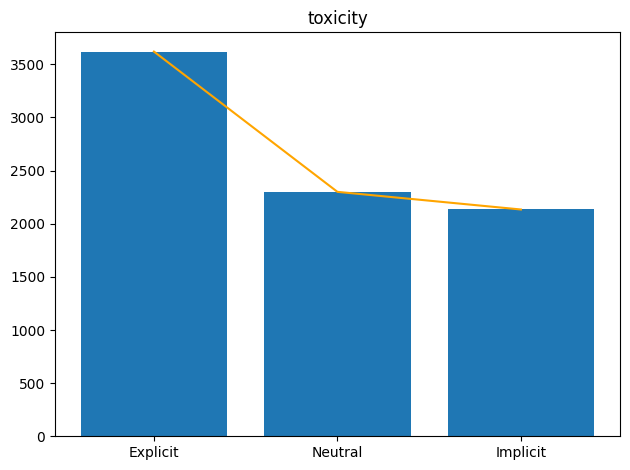

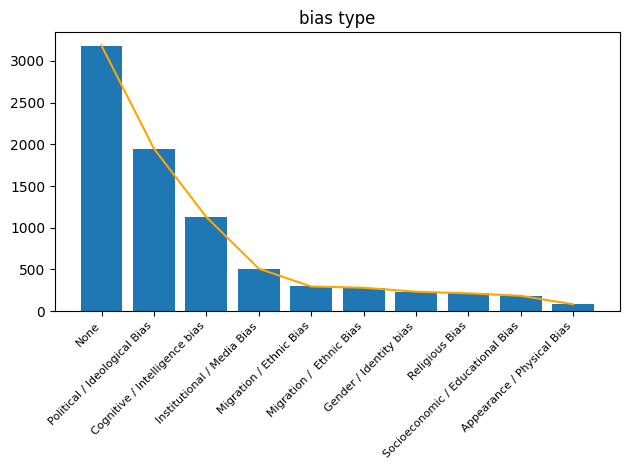

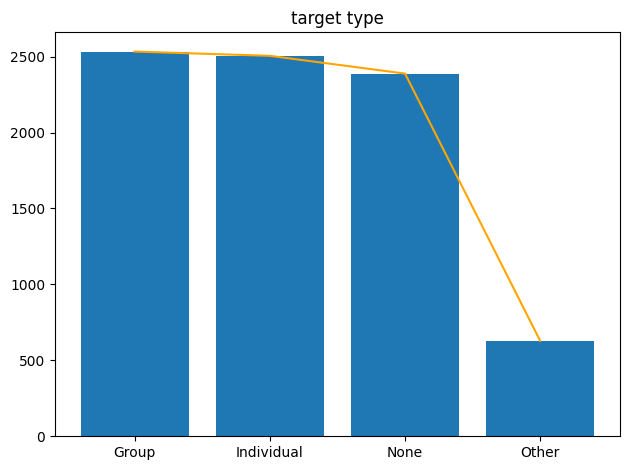

In [ ]:
# Create stratified train/dev/test splits and report the class distribution after splitting.
# Safety check: stratified splitting requires enough samples in every class
counts = df["tox_id"].value_counts()
too_small = counts[counts < 100]
if len(too_small) > 0:
    print("⚠️ Warning: very small classes found (stratify may fail):")
    print(too_small)

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["tox_id"]
)

dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["tox_id"]
)

train_df = train_df.reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), "Dev:", len(dev_df), "Test:", len(test_df))

print("\nTrain toxicity distribution (prop%):")
print(train_df["toxicity"].value_counts(normalize=True).round(3) * 100)
print("Train toxicity distribution (count):")
print(train_df["toxicity"].value_counts())

print("\nDev toxicity distribution (prop%):")
print(dev_df["toxicity"].value_counts(normalize=True).round(3) * 100)
print("Dev toxicity distribution (count):")
print(dev_df["toxicity"].value_counts())

print("\nTest toxicity distribution (prop%):")
print(test_df["toxicity"].value_counts(normalize=True).round(3) * 100)
print("Test toxicity distribution (count):")
print(test_df["toxicity"].value_counts())

print("="*30)

print("\nTrain bias distribution (prop%):")
print(train_df["bias_type"].value_counts(normalize=True).round(3) * 100)
print("Train bias distribution (count):")
print(train_df["bias_type"].value_counts())

print("\nDev bias distribution (prop%):")
print(dev_df["bias_type"].value_counts(normalize=True).round(3) * 100)
print("Dev bias distribution (count):")
print(dev_df["bias_type"].value_counts())

print("\nTest bias distribution (prop%):")
print(test_df["bias_type"].value_counts(normalize=True).round(3) * 100)
print("Test bias distribution (count):")
print(test_df["bias_type"].value_counts())

print("="*30)

print("\nTrain target distribution (prop%):")
print(train_df["target_type"].value_counts(normalize=True).round(3) * 100)
print("Train target distribution (count):")
print(train_df["target_type"].value_counts())

print("\nDev target distribution (prop%):")
print(dev_df["target_type"].value_counts(normalize=True).round(3) * 100)
print("Dev target distribution (count):")
print(dev_df["target_type"].value_counts())

print("\nTest target distribution (prop%):")
print(test_df["target_type"].value_counts(normalize=True).round(3) * 100)
print("Test target distribution (count):")
print(test_df["target_type"].value_counts())

if not os.path.exists(os.path.join(BasePath, "emobot_de", "images")):
    os.makedirs(os.path.join(BasePath, "emobot_de", "images"))

plt.figure()
plt.bar(df_raw["toxicity"].value_counts().index,
        df_raw["toxicity"].value_counts().values)
plt.plot(df_raw["toxicity"].value_counts().values, color="orange")
plt.title("toxicity")
plt.tight_layout()
plt.savefig(os.path.join(BasePath, "emobot_de", "images",
            "toxicity_distribution.png"), dpi=200)

plt.figure()
plt.bar(df_raw["bias_type"].value_counts().index,
        df_raw["bias_type"].value_counts().values)
plt.plot(df_raw["bias_type"].value_counts().values, color="orange")
plt.title("bias type")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BasePath, "emobot_de", "images",
            "bias_type_distribution.png"), dpi=200)

plt.figure()
plt.bar(df_raw["target_type"].value_counts().index,
        df_raw["target_type"].value_counts().values)
plt.plot(df_raw["target_type"].value_counts().values, color="orange")
plt.title("target type")
plt.tight_layout()
plt.savefig(os.path.join(BasePath, "emobot_de", "images",
            "target_type_distribution.png"), dpi=200)

In [ ]:
# Model definition: encoder backbone, classification heads, weighted multitask loss, and optimizer setup helpers.
@dataclass
class ModelConfig:
    model_name: str = None
    dropout: float = 0.1
    tox_weight: float = 1.0
    bias_weight: float = 0.7
    tgt_weight: float = 0.7
    # masking: Neutral -> no bias/target loss
    neutral_id: int = toxicity2id["Neutral"]


class_weights_tox = torch.tensor(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["tox_id"].to_numpy()),
    y=df["tox_id"].to_numpy()
)).to(dtype=torch.float32)

class_weights_bias = torch.tensor(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["bias_id"].to_numpy()),
    y=df["bias_id"].to_numpy()
)).to(dtype=torch.float32)

class_weights_tgt = torch.tensor(compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["tgt_id"].to_numpy()),
    y=df["tgt_id"].to_numpy()
)).to(dtype=torch.float32)


class GermanToxicityMultiTask(nn.Module):
    """
    Multi-task (single-choice) model:
      1) Toxicity: 3-class softmax
      2) Bias: 9-class softmax (incl. None)
      3) Target: 4-class softmax (incl. None)

    Masking:
      - bias/target loss is computed only when labels_tox != Neutral
    """

    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config

        if config.model_name == "deepset/gbert-base":
            self.encoder = BertModel.from_pretrained(
                config.model_name, torch_dtype=torch.float32)
        else:
            self.encoder = AutoModel.from_pretrained(
                config.model_name, torch_dtype=torch.float32)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(config.dropout)

        self.toxicity_classifier = nn.Linear(hidden_size, NUM_TOX)
        self.bias_classifier = nn.Linear(hidden_size, NUM_BIAS)
        self.target_classifier = nn.Linear(hidden_size, NUM_TARGET)

        self.ce_loss_tox = nn.CrossEntropyLoss(
            label_smoothing=0.1, weight=class_weights_tox)
        self.ce_loss_bias = nn.CrossEntropyLoss(
            label_smoothing=0.1, weight=class_weights_bias)
        self.ce_loss_tgt = nn.CrossEntropyLoss(
            label_smoothing=0.1, weight=class_weights_tgt)

    def forward(
        self,
        input_ids,
        attention_mask,
        labels_tox=None,
        labels_bias=None,
        labels_tgt=None,
    ):
        enc_out = self.encoder(input_ids=input_ids,
                               attention_mask=attention_mask)
        cls_repr = enc_out.last_hidden_state[:, 0, :]
        cls_repr = self.dropout(cls_repr)

        tox_logits = self.toxicity_classifier(cls_repr)
        bias_logits = self.bias_classifier(cls_repr)
        tgt_logits = self.target_classifier(cls_repr)

        loss = None
        if labels_tox is not None:
            loss_tox = self.ce_loss_tox(tox_logits, labels_tox)

            toxic_mask = (labels_tox != self.config.neutral_id)

            # default zero loss for the subtasks
            loss_bias = torch.tensor(0.0, device=tox_logits.device)
            loss_tgt = torch.tensor(0.0, device=tox_logits.device)

            # bias loss only on toxic samples (if labels provided)
            if labels_bias is not None and toxic_mask.any():
                loss_bias = self.ce_loss_bias(
                    bias_logits[toxic_mask], labels_bias[toxic_mask])

            # target loss only on toxic samples (if labels provided)
            if labels_tgt is not None and toxic_mask.any():
                loss_tgt = self.ce_loss_tgt(
                    tgt_logits[toxic_mask], labels_tgt[toxic_mask])

            loss = (
                self.config.tox_weight * loss_tox
                + self.config.bias_weight * loss_bias
                + self.config.tgt_weight * loss_tgt
            )

        return {
            "loss": loss,
            "toxicity_logits": tox_logits,
            "bias_logits": bias_logits,
            "target_logits": tgt_logits,
        }


# megalitero baros = ligotera deigmata
print("Toxicity weights")
print(tuple(f"{name}: {w:.4f}" for name, w in zip(
    toxicity2id.keys(), class_weights_tox)))

print("Bias weights")
print(tuple(f"{name}: {w:.4f}" for name, w in zip(
    bias2id.keys(), class_weights_bias)))

print("Target weights")
print(tuple(f"{name}: {w:.4f}" for name, w in zip(
    target2id.keys(), class_weights_tgt)))

Toxicity weights
('Explicit: 0.7416', 'Implicit: 1.2580', 'Neutral: 1.1672')
Bias weights
('Political / Ideological Bias: 0.4594', 'Migration / Ethnic Bias: 1.5563', 'Religious Bias: 4.2014', 'Institutional / Media Bias: 1.7581', 'Socioeconomic / Educational Bias: 4.8901', 'Cognitive / Intelligence bias: 0.7933', 'Gender / Identity bias: 3.8573', 'Appearance / Physical Bias: 11.0480', 'None: 0.2810')
Target weights
('Individual: 0.8057', 'Group: 0.7949', 'Other: 3.2113', 'None: 0.8407')


In [ ]:
# Training loop for one epoch with gradient clipping and scheduler updates.
def train_one_epoch(model, dataloader, optimizer, scheduler, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc="Training  "):
        batch = {
            k: v.to(device) if torch.is_tensor(v) else v
            for k, v in batch.items()
        }

        optimizer.zero_grad(set_to_none=True)

        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels_tox=batch["labels_tox"],
            labels_bias=batch["labels_bias"],
            labels_tgt=batch["labels_tgt"],
        )

        loss = out["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

    return total_loss / max(1, len(dataloader))

In [ ]:
# Evaluation loop that computes losses, predictions, and task-specific metrics on a dataloader.
@torch.no_grad()
def evaluate(model, dataloader, device, neutral_id: int):
    model.eval()

    all_tox_true, all_tox_pred = [], []
    all_bias_true, all_bias_pred = [], []
    all_tgt_true, all_tgt_pred = [], []

    all_bias_true_toxic, all_bias_pred_toxic = [], []
    all_tgt_true_toxic, all_tgt_pred_toxic = [], []

    total_loss = 0.0

    res = {
        "text": [],
        "tox_true": [],
        "tox_pred": [],
        "bias_true": [],
        "bias_pred": [],
        "tgt_true": [],
        "tgt_pred": [],
    }

    for batch in tqdm(dataloader, desc="Evaluating"):
        batch = {
            k: v.to(device) if torch.is_tensor(v) else v
            for k, v in batch.items()
        }

        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels_tox=batch["labels_tox"],
            labels_bias=batch["labels_bias"],
            labels_tgt=batch["labels_tgt"],
        )

        loss = out["loss"]
        total_loss += float(loss.item()) if loss is not None else 0.0

        tox_pred = out["toxicity_logits"].argmax(dim=1)
        bias_pred = out["bias_logits"].argmax(dim=1)
        tgt_pred = out["target_logits"].argmax(dim=1)

        labels_tox = batch["labels_tox"]
        labels_bias = batch["labels_bias"]
        labels_tgt = batch["labels_tgt"]

        all_tox_true.extend(labels_tox.detach().cpu().numpy())
        all_tox_pred.extend(tox_pred.detach().cpu().numpy())

        all_bias_true.extend(labels_bias.detach().cpu().numpy())
        all_bias_pred.extend(bias_pred.detach().cpu().numpy())

        all_tgt_true.extend(labels_tgt.detach().cpu().numpy())
        all_tgt_pred.extend(tgt_pred.detach().cpu().numpy())

        toxic_mask = (labels_tox != neutral_id)
        if toxic_mask.any():
            all_bias_true_toxic.extend(
                labels_bias[toxic_mask].detach().cpu().numpy())
            all_bias_pred_toxic.extend(
                bias_pred[toxic_mask].detach().cpu().numpy())

            all_tgt_true_toxic.extend(
                labels_tgt[toxic_mask].detach().cpu().numpy())
            all_tgt_pred_toxic.extend(
                tgt_pred[toxic_mask].detach().cpu().numpy())

        res["text"].extend(batch["text"])
        res["tox_true"].extend(labels_tox.detach().cpu().numpy())
        res["tox_pred"].extend(tox_pred.detach().cpu().numpy())
        res["bias_true"].extend(labels_bias.detach().cpu().numpy())
        res["bias_pred"].extend(bias_pred.detach().cpu().numpy())
        res["tgt_true"].extend(labels_tgt.detach().cpu().numpy())
        res["tgt_pred"].extend(tgt_pred.detach().cpu().numpy())

    metrics = {
        "loss": total_loss / max(1, len(dataloader)),

        "tox_acc": accuracy_score(all_tox_true, all_tox_pred),
        "tox_f1_macro": f1_score(all_tox_true, all_tox_pred, average="macro", zero_division=0),
        "tox_recall_macro": recall_score(all_tox_true, all_tox_pred, average="macro", zero_division=0),
        "tox_precision_macro": precision_score(all_tox_true, all_tox_pred, average="macro", zero_division=0),
        "tox_report": classification_report(all_tox_true, all_tox_pred, zero_division=0, target_names=toxicity_labels),

        # keep these for monitoring, but main KPIs are toxic-only:
        "bias_acc": accuracy_score(all_bias_true, all_bias_pred),
        "bias_f1_macro": f1_score(all_bias_true, all_bias_pred, average="macro", zero_division=0),
        "bias_recall_macro": recall_score(all_bias_true, all_bias_pred, average="macro", zero_division=0),
        "bias_precision_macro": precision_score(all_bias_true, all_bias_pred, average="macro", zero_division=0),
        "bias_report": classification_report(all_bias_true, all_bias_pred, zero_division=0, target_names=bias_labels),

        "tgt_acc": accuracy_score(all_tgt_true, all_tgt_pred),
        "tgt_f1_macro": f1_score(all_tgt_true, all_tgt_pred, average="macro", zero_division=0),
        "tgt_recall_macro": recall_score(all_tgt_true, all_tgt_pred, average="macro", zero_division=0),
        "tgt_precision_macro": precision_score(all_tgt_true, all_tgt_pred, average="macro", zero_division=0),
        "tgt_report": classification_report(all_tgt_true, all_tgt_pred, zero_division=0, target_names=target_labels),
    }

    if len(all_bias_true_toxic) > 0:
        metrics["bias_acc_toxic_only"] = accuracy_score(
            all_bias_true_toxic, all_bias_pred_toxic)
        metrics["bias_f1_macro_toxic_only"] = f1_score(
            all_bias_true_toxic, all_bias_pred_toxic, average="macro", zero_division=0)

    if len(all_tgt_true_toxic) > 0:
        metrics["tgt_acc_toxic_only"] = accuracy_score(
            all_tgt_true_toxic, all_tgt_pred_toxic)
        metrics["tgt_f1_macro_toxic_only"] = f1_score(
            all_tgt_true_toxic, all_tgt_pred_toxic, average="macro", zero_division=0)

    return metrics, res

In [ ]:
# End-to-end experiment runner: tokenization, dataloaders, training, checkpointing, and test evaluation.
neutral_id = toxicity2id["Neutral"]

train_ds = EmobotDataset(train_df, tokenizer=None,
                         max_len=MAX_LENGTH, apply_preproc=True)
dev_ds = EmobotDataset(dev_df, tokenizer=None,
                       max_len=MAX_LENGTH, apply_preproc=True)
test_ds = EmobotDataset(test_df, tokenizer=None,
                        max_len=MAX_LENGTH, apply_preproc=True)

best_model = {
    "model": [],
    "epoch": [],
    "tox": [],
    "bias": [],
    "tgt": []
}

for model_name in models:
    print("\n", f" {model_name} ".center(60, '='))
    if model_name in ["deepset/gbert-base", "deepset/gelectra-large","deepset/bert-base-german-cased-hatespeech-GermEval18Coarse "]:
        tokenizer = BertTokenizer.from_pretrained(model_name)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    train_ds.tokenizer = tokenizer
    dev_ds.tokenizer = tokenizer
    test_ds.tokenizer = tokenizer

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
    dev_loader = DataLoader(dev_ds,   batch_size=BATCH_SIZE,
                            shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(
        test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    cfg = ModelConfig(
        model_name=model_name,
        dropout=0.1,
        tox_weight=1.0,
        bias_weight=0.7,
        tgt_weight=0.7,
        neutral_id=neutral_id
    )

    model = GermanToxicityMultiTask(cfg).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    num_training_steps = EPOCHS * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * num_training_steps),
        num_training_steps=num_training_steps,
    )

    best_model_path = os.path.join(
        OUTPUT_DIR, model_name.split("/")[-1], "best_model_de.pt")
    best_tokenizer_dir = os.path.join(
        OUTPUT_DIR, model_name.split("/")[-1], "best_tokenizer_de")

    best_dev_f1 = float("-inf")
    patience = 20 #4 #2
    no_improve = 0
    min_delta = 1e-4

    os.makedirs(os.path.dirname(best_model_path), exist_ok=True)
    cfg_path = os.path.join(os.path.dirname(best_model_path), "config_de.json")

    try:
        with open(cfg_path, "w", encoding="utf-8") as f:
            json.dump(cfg.__dict__, f, ensure_ascii=False, indent=2)
    except Exception as e:
        pass

    stats = {}
    plots_data = {
        "tox_f1": [],
        "bias_f1": [],
        "tgt_f1": []
    }
    for epoch in range(1, EPOCHS + 1):
        print(f"\n\tEpoch {epoch}/{EPOCHS}")

        train_loss = train_one_epoch(
            model, train_loader, optimizer, scheduler, device)
        dev_metrics, _ = evaluate(
            model, dev_loader, device, neutral_id=neutral_id)

        stats[epoch] = {
            "train_loss": train_loss,
            "dev_loss": dev_metrics['loss'],
            "dev_tox_f1_macro": dev_metrics['tox_f1_macro'],
            "dev_tox_acc": dev_metrics['tox_acc'],
            "bias_f1_macro_toxic_only": dev_metrics['bias_f1_macro_toxic_only'],
            "bias_acc_toxic_only": dev_metrics.get('bias_acc_toxic_only', float('nan')),
            "tgt_f1_macro_toxic_only": dev_metrics['tgt_f1_macro_toxic_only'],
            "tgt_acc_toxic_only": dev_metrics.get('tgt_acc_toxic_only', float('nan'))
        }

        print(
            f"\tDev Toxicity F1 macro: {dev_metrics['tox_f1_macro']:.4f}, Acc: {dev_metrics['tox_acc']:.4f}")

        plots_data["tox_f1"].append(dev_metrics['tox_f1_macro'])
        plots_data["bias_f1"].append(dev_metrics['bias_f1_macro'])
        plots_data["tgt_f1"].append(dev_metrics['tgt_f1_macro'])

        improved = dev_metrics["tox_f1_macro"] > best_dev_f1 + min_delta

        if improved:
            best_dev_f1 = dev_metrics["tox_f1_macro"]
            no_improve = 0

            torch.save(model.state_dict(), best_model_path)
            tokenizer.save_pretrained(best_tokenizer_dir)

            if model_name.split("/")[-1] in best_model['model']:
                idx = best_model["model"].index(model_name.split("/")[-1])
                best_model["epoch"][idx] = epoch
                best_model["tox"][idx] = dev_metrics['tox_f1_macro']
                best_model["bias"][idx] = dev_metrics['bias_f1_macro']
                best_model["tgt"][idx] = dev_metrics['tgt_f1_macro']
            else:
                best_model["epoch"].append(epoch)
                best_model["tox"].append(dev_metrics['tox_f1_macro'])
                best_model["bias"].append(dev_metrics['bias_f1_macro'])
                best_model["tgt"].append(dev_metrics['tgt_f1_macro'])
                best_model["model"].append(model_name.split("/")[-1])

        else:
            no_improve += 1
            if no_improve >= patience:
                print("🛑 Early stopping triggered.")
                break

    print("\n\tTraining finished.")
    print(f"Best dev toxicity F1 macro: {best_dev_f1:.4f}")

    # ---- Load best + Test evaluation ----
    state = torch.load(best_model_path, map_location=device)
    model.load_state_dict(state)

    test_metrics, res = evaluate(
        model, test_loader, device, neutral_id=neutral_id)

    stats["testing_metrics"] = test_metrics

    res["bias_true"] = list(map(lambda x: id2bias[x], res["bias_true"]))
    res["bias_pred"] = list(map(lambda x: id2bias[x], res["bias_pred"]))
    res["tgt_true"] = list(map(lambda x: id2target[x], res["tgt_true"]))
    res["tgt_pred"] = list(map(lambda x: id2target[x], res["tgt_pred"]))
    res["tox_pred"] = list(map(lambda x: id2toxicity[x], res["tox_pred"]))
    res["tox_true"] = list(map(lambda x: id2toxicity[x], res["tox_true"]))

    res_df = pd.DataFrame(res)
    res_df.to_excel(os.path.join(OUTPUT_DIR,  model_name.split(
        "/")[-1], "test_predictions_de.xlsx"), index=False)

    with open(os.path.join(os.path.join(OUTPUT_DIR,  model_name.split("/")[-1], "overallStats.json")), "w") as f:
        json.dump(stats, f)

    os.makedirs(os.path.join(OUTPUT_DIR, model_name.split(
        "/")[-1], "stats"), exist_ok=True)
    plt.figure()
    plt.plot(range(1, len(plots_data["tgt_f1"]) + 1), plots_data["tox_f1"])
    plt.gca().set_xticks(range(1, len(plots_data["tgt_f1"]) + 1))
    plt.savefig(os.path.join(OUTPUT_DIR, model_name.split(
        "/")[-1], "stats", "toxicity.png"), dpi=200)

    plt.figure()
    plt.plot(range(1, len(plots_data["tgt_f1"]) + 1), plots_data["tgt_f1"])
    plt.gca().set_xticks(range(1, len(plots_data["tgt_f1"]) + 1))
    plt.savefig(os.path.join(OUTPUT_DIR, model_name.split(
        "/")[-1], "stats", "target.png"), dpi=200)

    plt.figure()
    plt.plot(range(1, len(plots_data["tgt_f1"]) + 1), plots_data["bias_f1"])
    plt.gca().set_xticks(range(1, len(plots_data["tgt_f1"]) + 1))
    plt.savefig(os.path.join(OUTPUT_DIR, model_name.split(
        "/")[-1], "stats", "bias.png"), dpi=200)

df = pd.DataFrame(best_model)
df = df.sort_values(by="tox", ascending=False)
df.to_excel(os.path.join(OUTPUT_DIR, "best_stats_per_model.xlsx"), index=False)

best_row = df.iloc[0]
print(
    f"best model: {best_row['model']}, toxicity: {best_row['tox']*100}%, bias: {best_row['bias']*100}%, target: {best_row['tgt']*100}%")

with open(os.path.join(OUTPUT_DIR, "BEST_MODEL.txt"), 'w') as f:
    f.write(f"""
toxicity : {best_row['tox']*100}%
bias     : {best_row['bias']*100}%
target   : {best_row['tgt']*100}%""")


 ================ LSX-UniWue/ModernGBERT_1B =================

	Epoch 1/20


Training  :   0%|          | 0/403 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 48.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 45.81 MiB is free. Including non-PyTorch memory, this process has 14.52 GiB memory in use. Of the allocated memory 14.38 GiB is allocated by PyTorch, and 12.75 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# DATA ANALYSIS

In [ ]:
# Import additional utilities for confusion matrices and post-hoc evaluation.
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [ ]:
# Plot the toxicity confusion matrix.
res_df = pd.DataFrame(res)

cm = confusion_matrix(res_df["tox_true"],
                      res_df["tox_pred"], labels=toxicity_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=toxicity_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Toxicity")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.savefig(os.path.join(
    OUTPUT_DIR, best_row['model'], "stats", "confusion_matrix_toxicity.png"), dpi=200)

In [ ]:
# Plot the bias-type confusion matrix.
cm = confusion_matrix(res_df["bias_true"],
                      res_df["bias_pred"], labels=bias_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bias_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Bias")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.setp(plt.gca().get_xticklabels(), rotation=90)

plt.savefig(os.path.join(
    OUTPUT_DIR, best_row['model'], "stats", "confusion_matrix_bias.png"), dpi=200)

In [ ]:
# Plot the target-type confusion matrix.
cm = confusion_matrix(res_df["tgt_true"],
                      res_df["tgt_pred"], labels=target_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=target_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Target")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.savefig(os.path.join(
    OUTPUT_DIR, best_row['model'], "stats", "confusion_matrix_target.png"), dpi=200)

In [ ]:
# Print the final classification reports and inspect a few prediction examples.

print(f"Classification Report - Toxicity\n{test_metrics['tox_report']}")
print(f"Classification Report - Bias\n{test_metrics['bias_report']}")
print(f"Classification Report - Target\n{test_metrics['tgt_report']}")

with open(os.path.join(OUTPUT_DIR, best_row['model'], "stats", "classification_report.txt"), 'w') as f:
    f.write(f"Classification Report - Toxicity\n{test_metrics['tox_report']}\n\n")
    f.write(f"Classification Report - Bias\n{test_metrics['bias_report']}\n\n")
    f.write(f"Classification Report - Target\n{test_metrics['tgt_report']}\n\n")